# EDA

Dataset shape: (520, 17)

First 5 rows:
   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class  


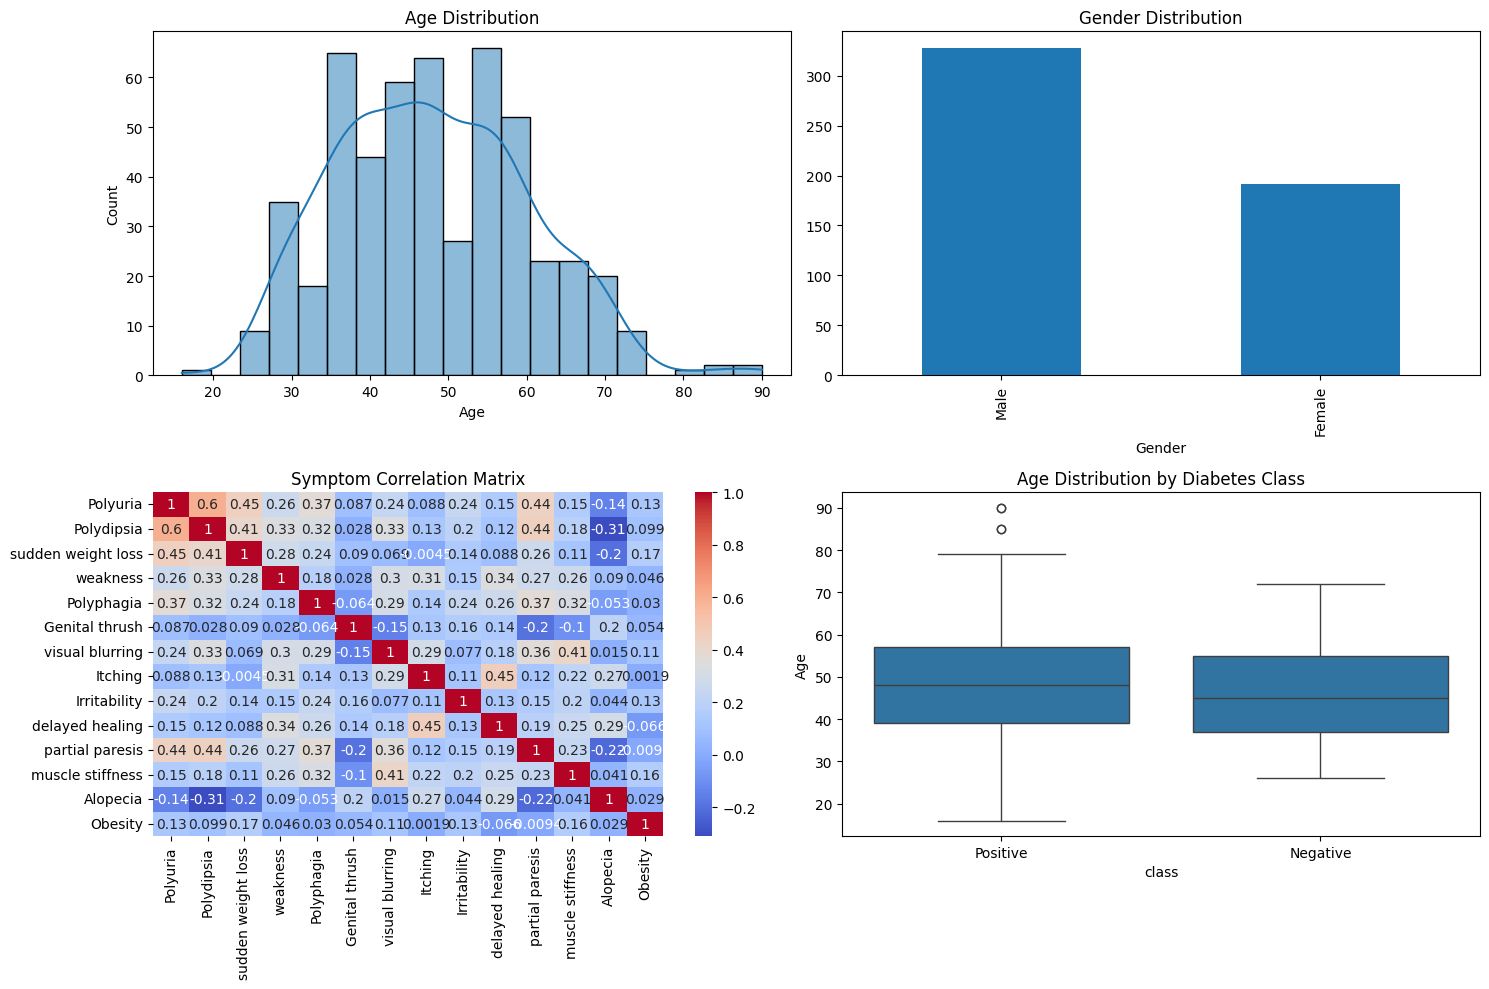

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
df = pd.read_csv('dataset/diabetes_data.csv')

# Initial EDA
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())
print("\nClass distribution:")
print(df['class'].value_counts())

# Visualizations
plt.figure(figsize=(15,10))

# Age distribution
plt.subplot(2,2,1)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')

# Gender distribution
plt.subplot(2,2,2)
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')

# Symptom correlations
plt.subplot(2,2,3)
symptoms = df.columns[2:-1]
sns.heatmap(df[symptoms].apply(lambda x: x.map({'Yes':1, 'No':0})).corr(), annot=True, cmap='coolwarm')
plt.title('Symptom Correlation Matrix')

# Class by age
plt.subplot(2,2,4)
sns.boxplot(x='class', y='Age', data=df)
plt.title('Age Distribution by Diabetes Class')

plt.tight_layout()
plt.show()

# Data PreProcessing

In [13]:
# Convert categorical to numerical 
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Convert binary columns (safer approach)
binary_columns = df.columns[2:-1]  # All columns between Gender and class
for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})  # Apply to each column individually

# Convert target variable
df['class'] = df['class'].map({'Positive': 1, 'Negative': 0})

# Check for class imbalance
print("\nClass balance after encoding:")
print(df['class'].value_counts())

# Handle imbalance if needed (using SMOTE)
if df['class'].value_counts()[0]/df['class'].value_counts()[1] > 1.5:
    from imblearn.over_sampling import SMOTE
    X = df.drop('class', axis=1)
    y = df['class']
    smote = SMOTE()
    X, y = smote.fit_resample(X, y)
    df = pd.concat([X, y], axis=1)
    print("\nAfter SMOTE balancing:")
    print(y.value_counts())


Class balance after encoding:
class
1    320
0    200
Name: count, dtype: int64


# Model Creation

In [14]:
# Check for NaN/infinite values
print("NaN values before cleaning:")
print(df.isna().sum())

# Replace infinite values and drop remaining NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Verify
print("\nNaN values after cleaning:")
print(df.isna().sum())

NaN values before cleaning:
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

NaN values after cleaning:
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64


In [15]:
# Split data
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and Evaluate


Model Evaluation:
Accuracy: 0.94

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        54
           1       0.96      0.95      0.96       102

    accuracy                           0.94       156
   macro avg       0.93      0.94      0.94       156
weighted avg       0.94      0.94      0.94       156


Confusion Matrix:
[[50  4]
 [ 5 97]]

Feature Importance:
               Feature  Importance
3           Polydipsia    1.737397
2             Polyuria    1.609789
10        Irritability    0.726105
7       Genital thrush    0.700903
12     partial paresis    0.562400
8      visual blurring    0.525851
4   sudden weight loss    0.452589
5             weakness    0.285040
6           Polyphagia    0.181839
14            Alopecia   -0.002411
15             Obesity   -0.120108
13    muscle stiffness   -0.189384
11     delayed healing   -0.319508
0                  Age   -0.393978
9              Itching   -0.971

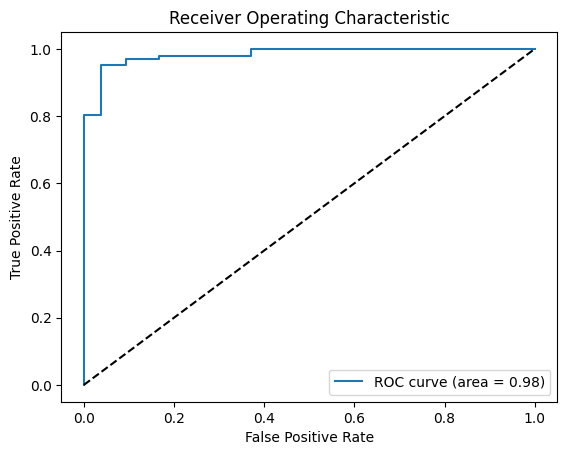

In [16]:
# Initialize and train model
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

# Predictions
y_pred = logreg.predict(X_test_scaled)
y_pred_prob = logreg.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature importance
coefficients = pd.DataFrame({'Feature': X.columns, 'Importance': logreg.coef_[0]})
coefficients = coefficients.sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(coefficients)

# ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()